# Airline Customer Value Data Analysis

## Project Overview

**Objective:** Segment 62K+ airline frequent flyer program members using the LRFMC framework and predict churn risk among loyal core customers for data-driven marketing and retention strategies.

**Dataset:** Airline frequent flyer program data with 41 features including flight frequency, mileage, membership duration, and points activity.

**Methods:**
- **Part 1 - Customer Segmentation:** K-Means clustering evaluated by Silhouette Score (optimal k=6) and Calinski-Harabasz Index (optimal k=4); selected k=5 as a business-driven compromise to identify 5 distinct customer segments
- **Part 2 - Churn Prediction:** LSTM neural network to predict churn probability for loyal core customers

**Business Value:** Targeted marketing strategies based on distinct customer value profiles and proactive retention for at-risk valuable customers.

In [1]:
import pandas as pd
import numpy as np
import warnings
import os
import copy
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, log_loss


warnings.filterwarnings('ignore')

airline_data = pd.read_csv('air_data.csv', encoding='utf-8')

In [2]:
airline_data.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,ADD_Point_SUM,Eli_Add_Point_Sum,L1Y_ELi_Add_Points,Points_Sum,L1Y_Points_Sum,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight
0,54993,2006/11/2,2008/12/24,Male,6,31.0,2014/3/31,210,505308,0,...,39992,114452,111100,619760,370211,0.509524,0.490476,0.487221,0.512777,50
1,28065,2007/2/19,2007/8/3,Male,6,42.0,2014/3/31,140,362480,0,...,12000,53288,53288,415768,238410,0.514286,0.485714,0.489289,0.510708,33
2,55106,2007/2/1,2007/8/30,Male,6,40.0,2014/3/31,135,351159,0,...,15491,55202,51711,406361,233798,0.518519,0.481481,0.481467,0.518530,26
3,21189,2008/8/22,2008/8/23,Male,5,64.0,2014/3/31,23,337314,0,...,0,34890,34890,372204,186100,0.434783,0.565217,0.551722,0.448275,12
4,39546,2009/4/10,2009/4/15,Male,6,48.0,2014/3/31,152,273844,0,...,22704,64969,64969,338813,210365,0.532895,0.467105,0.469054,0.530943,39


In [3]:
columns_set = set(airline_data.columns)
print(columns_set)

{'MAX_INTERVAL', 'Points_Sum', 'GENDER', 'avg_discount', 'Eli_Add_Point_Sum', 'FFP_DATE', 'BP_SUM', 'EP_SUM_YR_2', 'ADD_POINTS_SUM_YR_2', 'FLIGHT_COUNT', 'LAST_FLIGHT_DATE', 'WEIGHTED_SEG_KM', 'BEGIN_TO_FIRST', 'L1Y_BP_SUM', 'LOAD_TIME', 'AGE', 'ADD_POINTS_SUM_YR_1', 'P1Y_Flight_Count', 'AVG_BP_SUM', 'L1Y_Points_Sum', 'MEMBER_NO', 'EP_SUM_YR_1', 'SUM_YR_1', 'AVG_INTERVAL', 'P1Y_BP_SUM', 'Ration_L1Y_Flight_Count', 'Ration_P1Y_BPS', 'ADD_Point_SUM', 'FFP_TIER', 'EP_SUM', 'SEG_KM_SUM', 'L1Y_ELi_Add_Points', 'Ration_P1Y_Flight_Count', 'Ration_L1Y_BPS', 'L1Y_Flight_Count', 'LAST_TO_END', 'AVG_FLIGHT_COUNT', 'EXCHANGE_COUNT', 'FIRST_FLIGHT_DATE', 'Point_NotFlight', 'SUM_YR_2'}


###  Descriptive Data Analysis

In [4]:
airline_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MEMBER_NO                62988 non-null  int64  
 1   FFP_DATE                 62988 non-null  object 
 2   FIRST_FLIGHT_DATE        62988 non-null  object 
 3   GENDER                   62985 non-null  object 
 4   FFP_TIER                 62988 non-null  int64  
 5   AGE                      62568 non-null  float64
 6   LOAD_TIME                62988 non-null  object 
 7   FLIGHT_COUNT             62988 non-null  int64  
 8   BP_SUM                   62988 non-null  int64  
 9   EP_SUM_YR_1              62988 non-null  int64  
 10  EP_SUM_YR_2              62988 non-null  int64  
 11  SUM_YR_1                 62437 non-null  float64
 12  SUM_YR_2                 62850 non-null  float64
 13  SEG_KM_SUM               62988 non-null  int64  
 14  WEIGHTED_SEG_KM       

**Observations:**
- The dataset contains 44 columns (features) in total
- Most columns have 62,988 non-null values, indicating a largely complete dataset
- Key columns with missing values: WORK_CITY, WORK_PROVINCE, AGE, SUM_YR_1, SUM_YR_2
- Missing values in SUM_YR_1 and SUM_YR_2 (ticket prices) may indicate incomplete records and need to be addressed in preprocessing

### Data Preprocessing<br>
#### 1. Remove rows with empty ticket prices


In [5]:
# Ensure both first and second year ticket prices are not empty
exp1=airline_data['SUM_YR_1'].notnull()
exp2=airline_data['SUM_YR_2'].notnull()
exp=exp1&exp2
airline_notnull=airline_data.loc[exp,:]
airline_notnull.shape

(62299, 41)

#### 2. Retain only rows where the ticket price is not zero, the average discount rate is not zero, and the total flight kilometers is greater than zero.

In [6]:
index1=airline_notnull['SUM_YR_1']!=0
index2=airline_notnull['SUM_YR_2']!=0
index3=(airline_notnull['avg_discount']!=0)&(airline_notnull['SEG_KM_SUM']>0)
airline=airline_notnull[(index1|index2)&index3]
airline.shape

(62044, 41)

In [7]:
airline.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,ADD_Point_SUM,Eli_Add_Point_Sum,L1Y_ELi_Add_Points,Points_Sum,L1Y_Points_Sum,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight
0,54993,2006/11/2,2008/12/24,Male,6,31.0,2014/3/31,210,505308,0,...,39992,114452,111100,619760,370211,0.509524,0.490476,0.487221,0.512777,50
1,28065,2007/2/19,2007/8/3,Male,6,42.0,2014/3/31,140,362480,0,...,12000,53288,53288,415768,238410,0.514286,0.485714,0.489289,0.510708,33
2,55106,2007/2/1,2007/8/30,Male,6,40.0,2014/3/31,135,351159,0,...,15491,55202,51711,406361,233798,0.518519,0.481481,0.481467,0.518530,26
3,21189,2008/8/22,2008/8/23,Male,5,64.0,2014/3/31,23,337314,0,...,0,34890,34890,372204,186100,0.434783,0.565217,0.551722,0.448275,12
4,39546,2009/4/10,2009/4/15,Male,6,48.0,2014/3/31,152,273844,0,...,22704,64969,64969,338813,210365,0.532895,0.467105,0.469054,0.530943,39


### Feature Construction

#### L (Loyalty Duration): LOAD_TIME - FFP_DATE

LOAD_TIME: the end time of the observation window.
FFP_DATE: the date when the customer joined the frequent flyer program.
This difference gives the duration of loyalty and is converted into months for uniformity.

#### R (Recency): LAST_TO_END

LAST_TO_END represents the duration from the last flight to the end of the observation window.

#### F (Frequency): FLIGHT_COUNT 

FLIGHT_COUNT captures the number of flights taken by the customer during the observation window.

#### M (Miles Flown): SEG_KM_SUM

SEG_KM_SUM provides the total number of kilometers flown by the customer during the observation window.

#### C (Average Discount Rate): avg_discount

avg_discount represents the average discount availed, considering the booking class and its corresponding discount rate.

1. Select features based on the LRFMC order, and name it as airline_selection.
2. Construct the L feature by calculating the difference between the end time and join time. Convert to date format using pd.to_datetime() and get the duration in months.
3. Stack the L feature horizontally with the original data and name it airline_features.
4. Standardize the data using standard deviation. Since the five features have varying ranges, name the result airline_features_scaled.

### How to Interpret LRFMC Values

Cluster centers are reported in standardized units (z-scores). Higher or lower 
values carry different business meanings depending on the feature:

| Feature | Desired Direction | Interpretation |
|---------|---------------------|----------------|
| **L** (Loyalty Duration) | Higher is better | Longer-tenured members are more loyal |
| **R** (Recency) | Lower is better | Smaller gap since last flight = more active |
| **F** (Frequency) | Higher is better | More flights = higher engagement |
| **M** (Miles Flown) | Higher is better | More kilometers = higher revenue contribution |
| **C** (Discount Rate) | Context-dependent | High C signals price sensitivity / discount reliance |

In [8]:
# Based on LRFMC, select the features and name it as airline_selection
airline_selection=airline[['MEMBER_NO','LOAD_TIME',
                          'FFP_DATE',
                           'LAST_TO_END',
                           'FLIGHT_COUNT',
                           'SEG_KM_SUM',
                           'avg_discount']]
airline_selection.head()

,MEMBER_NO,LOAD_TIME,FFP_DATE,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
0,54993,2014/3/31,2006/11/2,1,210,580717,0.961639
1,28065,2014/3/31,2007/2/19,7,140,293678,1.252314
2,55106,2014/3/31,2007/2/1,11,135,283712,1.254676
3,21189,2014/3/31,2008/8/22,97,23,281336,1.090870
4,39546,2014/3/31,2009/4/10,5,152,309928,0.970658


In [9]:
airline_selection.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62044 entries, 0 to 62978
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MEMBER_NO     62044 non-null  int64  
 1   LOAD_TIME     62044 non-null  object 
 2   FFP_DATE      62044 non-null  object 
 3   LAST_TO_END   62044 non-null  int64  
 4   FLIGHT_COUNT  62044 non-null  int64  
 5   SEG_KM_SUM    62044 non-null  int64  
 6   avg_discount  62044 non-null  float64
dtypes: float64(1), int64(4), object(2)
memory usage: 3.8+ MB


## Part 1: Customer Segmentation (K-Means)

In [10]:
# Convert the data types from object to datetime for better date-time operations
airline_selection['LOAD_TIME']=pd.to_datetime(airline_selection['LOAD_TIME'])
airline_selection['FFP_DATE']=pd.to_datetime(airline_selection['FFP_DATE'])

In [11]:
airline_selection.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62044 entries, 0 to 62978
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   MEMBER_NO     62044 non-null  int64         
 1   LOAD_TIME     62044 non-null  datetime64[ns]
 2   FFP_DATE      62044 non-null  datetime64[ns]
 3   LAST_TO_END   62044 non-null  int64         
 4   FLIGHT_COUNT  62044 non-null  int64         
 5   SEG_KM_SUM    62044 non-null  int64         
 6   avg_discount  62044 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(4)
memory usage: 3.8 MB


In [12]:
airline_selection['L'] = (airline_selection['LOAD_TIME'] - airline_selection['FFP_DATE']).dt.days / 30
airline_selection['L'] = np.round(airline_selection['L'], 2)

airline_features = airline_selection[['MEMBER_NO', 'L', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']]

In [13]:
airline_features

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
0,54993,90.20,1,210,580717,0.961639
1,28065,86.57,7,140,293678,1.252314
2,55106,87.17,11,135,283712,1.254676
3,21189,68.23,97,23,281336,1.090870
4,39546,60.53,5,152,309928,0.970658
...,...,...,...,...,...,...
62974,11163,108.30,89,2,368,0.710000
62975,30765,65.37,121,2,368,0.670000
62976,10380,45.40,39,2,1062,0.225000
62977,16372,15.53,464,2,904,0.250000


In [14]:
airline_features.describe()

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
count,62044.000000,62044.000000,62044.000000,62044.000000,62044.000000,62044.000000
mean,31485.237928,49.623035,172.532703,11.971359,17321.694749,0.722180
std,18188.650537,28.262726,181.526164,14.110619,21052.728111,0.184833
min,1.000000,12.170000,1.000000,2.000000,368.000000,0.136017
25%,15715.750000,24.500000,29.000000,3.000000,4874.000000,0.613085
50%,31476.500000,42.600000,105.000000,7.000000,10200.000000,0.712162
75%,47247.250000,72.730000,260.000000,15.000000,21522.500000,0.809293
max,62988.000000,114.570000,731.000000,213.000000,580717.000000,1.500000


In [15]:
features_to_scale = ['L', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']

scaler = StandardScaler()
airline_features_scaled = airline_features.copy()   # Create a copy to preserve 'MEMBER_NO'
airline_features_scaled[features_to_scale] = scaler.fit_transform(airline_features[features_to_scale])
airline_features_scaled

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346
...,...,...,...,...,...,...
62974,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898
62975,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311
62976,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906
62977,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648


In [16]:
print(airline_features_scaled.columns.tolist())
print(airline_features_scaled.describe())

['MEMBER_NO', 'L', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']
          MEMBER_NO             L   LAST_TO_END  FLIGHT_COUNT    SEG_KM_SUM  \
count  62044.000000  6.204400e+04  6.204400e+04  6.204400e+04  6.204400e+04   
mean   31485.237928 -2.638596e-16  4.397660e-17  5.863547e-17 -1.026121e-16   
std    18188.650537  1.000008e+00  1.000008e+00  1.000008e+00  1.000008e+00   
min        1.000000 -1.325185e+00 -9.449552e-01 -7.066621e-01 -8.053033e-01   
25%    15715.750000 -8.889177e-01 -7.907062e-01 -6.357929e-01 -5.912676e-01   
50%    31476.500000 -2.484931e-01 -3.720304e-01 -3.523162e-01 -3.382817e-01   
75%    47247.250000  8.175840e-01  4.818479e-01  2.146373e-01  1.995389e-01   
max    62988.000000  2.297991e+00  3.076536e+00  1.424674e+01  2.676137e+01   

       avg_discount  
count  6.204400e+04  
mean   3.957894e-16  
std    1.000008e+00  
min   -3.171335e+00  
25%   -5.902378e-01  
50%   -5.419990e-02  
75%    4.713077e-01  
max    4.208258e+00  


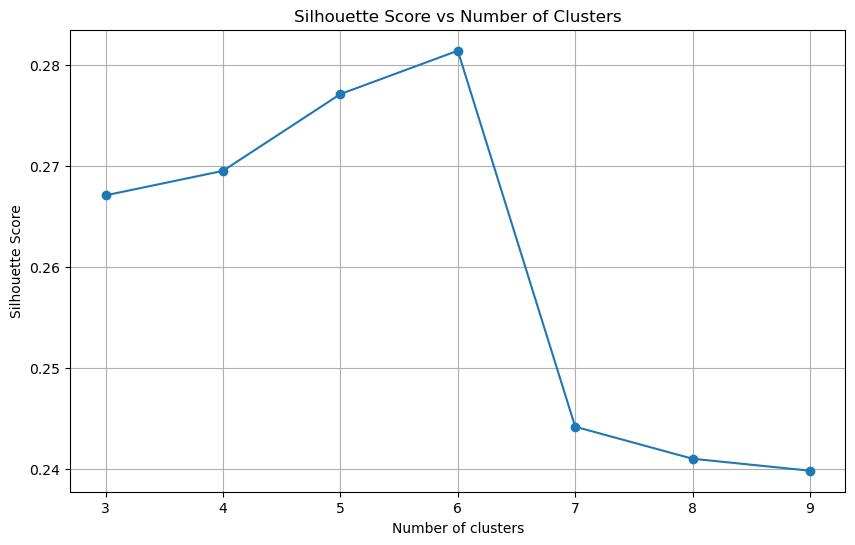

In [17]:
os.environ['OMP_NUM_THREADS'] = '5'

cluster_range = range(3, 10)
silhouette_scores = []
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=123, n_init=10)
    kmeans.fit(airline_features_scaled[features_to_scale])      
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(
        airline_features_scaled[features_to_scale], cluster_labels 
    )
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

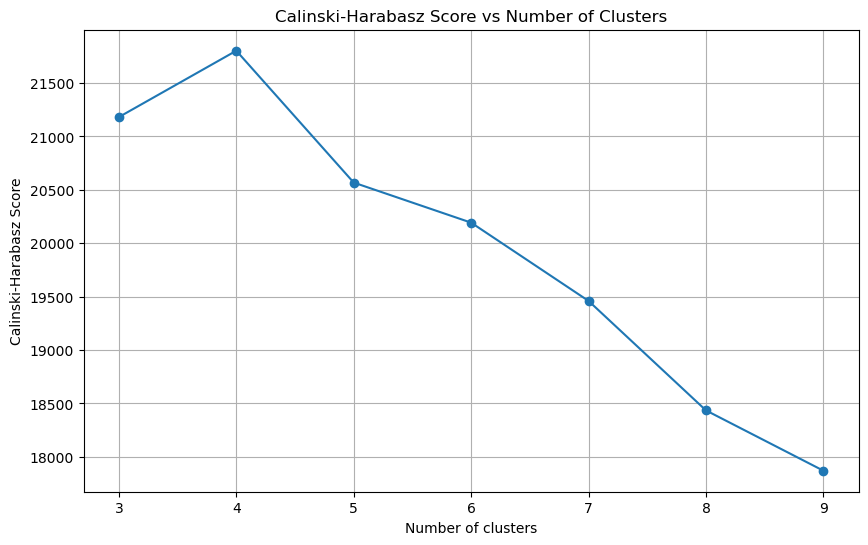

In [18]:
cluster_range = range(3, 10)
ch_scores = []
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(airline_features_scaled[features_to_scale])  # ← 加
    ch_score = calinski_harabasz_score(airline_features_scaled[features_to_scale], cluster_labels)  # ← 加
    ch_scores.append(ch_score)
    
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, ch_scores, marker='o')
plt.title('Calinski-Harabasz Score vs Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Score')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

### Using k-means

1. Import the k-means algorithm and initiate model training with an assumption of k=5
2. Obtain cluster labels and cluster centers
3. Count the number of samples in each cluster
4. Evaluate the clustering model and determine the optimal value for k
5. Save cluster center data to a DataFrame and subsequently export to an Excel file

In [19]:
k = 5

kmeans_model = KMeans(n_clusters=k, random_state=123, n_init=10).fit(airline_features_scaled[features_to_scale])

In [20]:
kmeans_model.labels_

array([2, 2, 2, ..., 0, 3, 3])

In [21]:
kmeans_model.cluster_centers_

array([[-0.70027966, -0.41513924, -0.16064317, -0.16034895, -0.25818629],
       [ 1.16106595, -0.37741348, -0.0865308 , -0.09442828, -0.15705928],
       [ 0.48355235, -0.79941328,  2.48315495,  2.42425727,  0.30978729],
       [-0.31307329,  1.68707882, -0.57391045, -0.53672535, -0.17546665],
       [ 0.04103354, -0.00252439, -0.23261276, -0.23699977,  2.16845378]])

In [22]:
df=pd.DataFrame(data=kmeans_model.cluster_centers_)
cluster_names = ['New Growth Customers', 'Loyal Core Customers',
                 'VIP Customers', 'Lapsed Customers', 'Discount-Sensitive Customers']
df.index = cluster_names
df.to_csv('df_with_names.csv')
df

,0,1,2,3,4
New Growth Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186
Loyal Core Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787
Lapsed Customers,-0.313073,1.687079,-0.573910,-0.536725,-0.175467
Discount-Sensitive Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454


### Cluster Naming Rationale

Each cluster is named based on which LRFMC dimensions stand out:

| Cluster | Standout Features | Interpretation |
|---------|-------------------|----------------|
| **New Growth Customers** | Low R (recently flew) but low L/F/M | Newest members, recently active but haven't built up frequency or miles yet |
| **Loyal Core Customers** | High L + active R | Longest-tenured members, still actively flying |
| **VIP Customers** | Very high F, M + low R | Top-tier: most flights, most miles, most recently active |
| **Lapsed Customers** | No standout advantage; R=+1.69 (longest gap since last flight) | Longest gap since last flight, low engagement across all dimensions |
| **Discount-Sensitive Customers** | Very high C (+2.17) only | Consistently book discounted fares, near-average on all other dimensions |

### Behavioral Analysis

Each segment is named based on its dominant LRFMC behavioral pattern:

**VIP Customers** have the highest flight frequency (F=+2.48) and total miles (M=+2.42), with the most recent activity (R=−0.80). They are the top revenue contributors and require premium service differentiation to prevent competitor poaching.

**Loyal Core Customers** have the longest membership duration (L=+1.16) and remain actively engaged. They have maintained consistent engagement over the longest membership period, and recognition of their loyalty is key to maintaining this relationship.

**New Growth Customers** are the newest members (L=−0.70) who have recently flown (R=−0.41) but have not yet built up frequency or miles. At 39.7% of the base, this is the largest segment and the primary growth engine. The onboarding experience in their first few months determines whether they graduate into Loyal Core or lapse into inactivity.

**Lapsed Customers** show the longest gap since their last flight (R=+1.69) with all other metrics below average. Their low frequency (F=−0.57) and short tenure (L=−0.31) suggest they never developed strong engagement with the program before becoming inactive. Thus, reactivation efforts should be low-cost and time-limited to test responsiveness before committing significant resources.

**Discount-Sensitive Customers** have near-average behavior across all dimensions except an extremely high discount rate (C=+2.17). They consistently book discounted fare classes. Rather than trying to shift them to premium fares, the optimal strategy is to channel them toward off-peak and low load factor routes where their bookings fill otherwise empty seats, generating positive marginal revenue.

In [23]:
s1=pd.Series(kmeans_model.labels_)
label_counts = s1.value_counts().sort_index()
for idx, name in enumerate(cluster_names):
    print(f'{name}: {label_counts[idx]}')

New Growth Customers: 24611
Loyal Core Customers: 15728
VIP Customers: 5337
Lapsed Customers: 12111
Discount-Sensitive Customers: 4257


In [24]:
airline_features['id']=airline['MEMBER_NO']
airline_features['label']=kmeans_model.labels_
airline_features.head()

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,id,label
0,54993,90.20,1,210,580717,0.961639,54993,2
1,28065,86.57,7,140,293678,1.252314,28065,2
2,55106,87.17,11,135,283712,1.254676,55106,2
3,21189,68.23,97,23,281336,1.090870,21189,2
4,39546,60.53,5,152,309928,0.970658,39546,2


In [25]:
airline_0=airline_features[airline_features['label']==0]
airline_1=airline_features[airline_features['label']==1]
airline_2=airline_features[airline_features['label']==2]
airline_3=airline_features[airline_features['label']==3]
airline_4=airline_features[airline_features['label']==4]

In [26]:
writer=pd.ExcelWriter('airline.xlsx')
airline_0.to_excel(writer,'New Growth Customers')
airline_1.to_excel(writer,'Loyal Core Customers')
airline_2.to_excel(writer,'VIP Customers')
airline_3.to_excel(writer,'Lapsed Customers')
airline_4.to_excel(writer,'Discount-Sensitive Customers')
writer.save()

### Data Visualization: Insight from Enhanced Customer Segmentation

In [27]:
df_with_names = pd.read_csv('df_with_names.csv', index_col=0)
df_with_names

,0,1,2,3,4
New Growth Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186
Loyal Core Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787
Lapsed Customers,-0.313073,1.687079,-0.573910,-0.536725,-0.175467
Discount-Sensitive Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454


In [28]:
df_with_names.columns = ['LOAD_TIME', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'AVG_DISCOUNT']
df_with_names

,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,AVG_DISCOUNT
New Growth Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186
Loyal Core Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787
Lapsed Customers,-0.313073,1.687079,-0.573910,-0.536725,-0.175467
Discount-Sensitive Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454


In [29]:
df_with_names['Advantage'] = ['R', 'L,R', 'F,M,R', 'None', 'C']
df_with_names['Sample_Count'] = [24611, 15728, 5337, 12111, 4257]
df_with_names['Marketing_Strategy'] = [
    'Post-enrollment bonuses and route recommendations to build flying habits', 
    'Anniversary rewards and tier upgrades to reinforce loyalty', 
    'Dedicated support, complimentary upgrades, exclusive events', 
    'Low-cost reactivation offers and status reinstatement challenges', 
    'Promotional fares on off-peak routes to fill underutilized capacity'
]

df_with_names

,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,AVG_DISCOUNT,Advantage,Sample_Count,Marketing_Strategy
New Growth Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186,R,24611,Post-enrollment bonuses and route recommendati...
Loyal Core Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059,"L,R",15728,Anniversary rewards and tier upgrades to reinf...
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787,"F,M,R",5337,"Dedicated support, complimentary upgrades, exc..."
Lapsed Customers,-0.313073,1.687079,-0.573910,-0.536725,-0.175467,None,12111,Low-cost reactivation offers and status reinst...
Discount-Sensitive Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454,C,4257,Promotional fares on off-peak routes to fill u...


In [30]:
df_with_names.index.name = 'Customer Value Labels'
df_with_names.columns = ['LOAD_TIME', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'AVG_DISCOUNT', 'Advantage', 'Sample_Count', 'Marketing_Strategy']
df_with_names

,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,AVG_DISCOUNT,Advantage,Sample_Count,Marketing_Strategy
Customer Value Labels,,,,,,,,
New Growth Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186,R,24611,Post-enrollment bonuses and route recommendati...
Loyal Core Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059,"L,R",15728,Anniversary rewards and tier upgrades to reinf...
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787,"F,M,R",5337,"Dedicated support, complimentary upgrades, exc..."
Lapsed Customers,-0.313073,1.687079,-0.573910,-0.536725,-0.175467,None,12111,Low-cost reactivation offers and status reinst...
Discount-Sensitive Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454,C,4257,Promotional fares on off-peak routes to fill u...


In [31]:
airline.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,ADD_Point_SUM,Eli_Add_Point_Sum,L1Y_ELi_Add_Points,Points_Sum,L1Y_Points_Sum,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight
0,54993,2006/11/2,2008/12/24,Male,6,31.0,2014/3/31,210,505308,0,...,39992,114452,111100,619760,370211,0.509524,0.490476,0.487221,0.512777,50
1,28065,2007/2/19,2007/8/3,Male,6,42.0,2014/3/31,140,362480,0,...,12000,53288,53288,415768,238410,0.514286,0.485714,0.489289,0.510708,33
2,55106,2007/2/1,2007/8/30,Male,6,40.0,2014/3/31,135,351159,0,...,15491,55202,51711,406361,233798,0.518519,0.481481,0.481467,0.518530,26
3,21189,2008/8/22,2008/8/23,Male,5,64.0,2014/3/31,23,337314,0,...,0,34890,34890,372204,186100,0.434783,0.565217,0.551722,0.448275,12
4,39546,2009/4/10,2009/4/15,Male,6,48.0,2014/3/31,152,273844,0,...,22704,64969,64969,338813,210365,0.532895,0.467105,0.469054,0.530943,39


In [32]:
kmeans = KMeans(n_clusters=5, random_state=123)
airline_features_scaled['cluster'] = kmeans.fit_predict(airline_features_scaled)
airline_features_scaled

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551,0
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199,3
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973,0
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730,1
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346,4
...,...,...,...,...,...,...,...
62974,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898,2
62975,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311,3
62976,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906,2
62977,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648,1


In [33]:
airline_features_scaled['Cluster'] = kmeans_model.labels_

In [34]:
airline_features_scaled

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster,Cluster
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551,0,2
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199,3,2
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973,0,2
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730,1,2
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346,4,2
...,...,...,...,...,...,...,...,...
62974,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898,2,1
62975,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311,3,1
62976,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906,2,0
62977,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648,1,3


In [35]:
airline_features_scaled.rename(columns={'L': 'LOAD_TIME'}, inplace=True)

In [36]:
cluster_mapping = {
    0: 'New Growth Customers',
    1: 'Loyal Core Customers',
    2: 'VIP Customers',
    3: 'Lapsed Customers',
    4: 'Discount-Sensitive Customers'
}

airline_features_scaled['Customer Value Labels'] = airline_features_scaled['Cluster'].map(cluster_mapping)
airline_features_scaled

,MEMBER_NO,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster,Cluster,Customer Value Labels
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551,0,2,VIP Customers
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199,3,2,VIP Customers
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973,0,2,VIP Customers
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730,1,2,VIP Customers
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346,4,2,VIP Customers
...,...,...,...,...,...,...,...,...,...
62974,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898,2,1,Loyal Core Customers
62975,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311,3,1,Loyal Core Customers
62976,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906,2,0,New Growth Customers
62977,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648,1,3,Lapsed Customers


In [37]:
df_with_names.reset_index(inplace=True)
df_with_names

,Customer Value Labels,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,AVG_DISCOUNT,Advantage,Sample_Count,Marketing_Strategy
0,New Growth Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186,R,24611,Post-enrollment bonuses and route recommendati...
1,Loyal Core Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059,"L,R",15728,Anniversary rewards and tier upgrades to reinf...
2,VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787,"F,M,R",5337,"Dedicated support, complimentary upgrades, exc..."
3,Lapsed Customers,-0.313073,1.687079,-0.573910,-0.536725,-0.175467,None,12111,Low-cost reactivation offers and status reinst...
4,Discount-Sensitive Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454,C,4257,Promotional fares on off-peak routes to fill u...


In [38]:
airline_features_scaled = pd.merge(
    airline_features_scaled, 
    df_with_names[['Customer Value Labels', 'Advantage', 'Sample_Count', 'Marketing_Strategy']],
    on='Customer Value Labels', 
    how='left'
)
airline_features_scaled

,MEMBER_NO,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster,Cluster,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551,0,2,VIP Customers,"F,M,R",5337,"Dedicated support, complimentary upgrades, exc..."
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199,3,2,VIP Customers,"F,M,R",5337,"Dedicated support, complimentary upgrades, exc..."
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973,0,2,VIP Customers,"F,M,R",5337,"Dedicated support, complimentary upgrades, exc..."
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730,1,2,VIP Customers,"F,M,R",5337,"Dedicated support, complimentary upgrades, exc..."
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346,4,2,VIP Customers,"F,M,R",5337,"Dedicated support, complimentary upgrades, exc..."
...,...,...,...,...,...,...,...,...,...,...,...,...
62039,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898,2,1,Loyal Core Customers,"L,R",15728,Anniversary rewards and tier upgrades to reinf...
62040,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311,3,1,Loyal Core Customers,"L,R",15728,Anniversary rewards and tier upgrades to reinf...
62041,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906,2,0,New Growth Customers,R,24611,Post-enrollment bonuses and route recommendati...
62042,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648,1,3,Lapsed Customers,None,12111,Low-cost reactivation offers and status reinst...


In [39]:
airline_data = pd.merge(
    airline_data,
    airline_features_scaled[['MEMBER_NO', 'LOAD_TIME', 'Customer Value Labels', 'Advantage', 'Sample_Count', 'Marketing_Strategy']],
    on='MEMBER_NO',
    how='left'
)
airline_data.head(10)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME_x,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy
0,54993,2006/11/2,2008/12/24,Male,6,31.0,2014/3/31,210,505308,0,...,0.509524,0.490476,0.487221,0.512777,50,1.435718,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
1,28065,2007/2/19,2007/8/3,Male,6,42.0,2014/3/31,140,362480,0,...,0.514286,0.485714,0.489289,0.510708,33,1.307279,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
2,55106,2007/2/1,2007/8/30,Male,6,40.0,2014/3/31,135,351159,0,...,0.518519,0.481481,0.481467,0.518530,26,1.328508,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
3,21189,2008/8/22,2008/8/23,Male,5,64.0,2014/3/31,23,337314,0,...,0.434783,0.565217,0.551722,0.448275,12,0.658362,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
4,39546,2009/4/10,2009/4/15,Male,6,48.0,2014/3/31,152,273844,0,...,0.532895,0.467105,0.469054,0.530943,39,0.385917,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
5,56972,2008/2/10,2009/9/29,Male,6,64.0,2014/3/31,92,313338,0,...,0.456522,0.543478,0.608233,0.391764,15,0.887288,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
6,44924,2006/3/22,2006/3/29,Male,6,46.0,2014/3/31,101,248864,0,...,0.504950,0.495050,0.495048,0.504948,29,1.701087,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
7,22631,2010/4/9,2010/4/9,Female,6,50.0,2014/3/31,73,301864,0,...,0.589041,0.410959,0.522078,0.477919,14,-0.043274,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
8,32197,2011/6/7,2011/7/1,Male,5,50.0,2014/3/31,56,262958,0,...,0.410714,0.589286,0.483459,0.516537,7,-0.543230,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."
9,31645,2010/7/5,2010/7/5,Female,6,43.0,2014/3/31,64,204855,0,...,0.390625,0.609375,0.526951,0.473044,16,-0.145884,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."


In [40]:
airline_data_sorted = airline_data.sort_values(by='MEMBER_NO')
airline_data_sorted.head(10)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME_x,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy
19774,1,2006/3/31,2007/1/13,Male,4,40.0,2014/3/31,3,7035,0,...,1.000000,0.000000,0.000000,0.999858,0,1.690472,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
10231,2,2006/3/31,2007/2/21,Male,4,52.0,2014/3/31,24,16210,0,...,0.458333,0.541667,0.585590,0.414348,0,1.690472,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
22550,3,2006/4/7,2006/4/7,Female,4,52.0,2014/3/31,9,7508,0,...,0.333333,0.666667,0.913171,0.086696,5,1.682334,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
20760,4,2006/8/10,2006/10/17,Male,4,45.0,2014/3/31,12,8092,0,...,0.333333,0.666667,0.754232,0.245644,13,1.534789,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
49925,5,2008/2/7,2008/9/11,Male,4,57.0,2014/3/31,3,2329,0,...,0.333333,0.666667,0.886266,0.113305,0,0.890826,Discount-Sensitive Customers,C,4257.0,Promotional fares on off-peak routes to fill u...
48618,6,2010/9/16,2012/12/24,Male,4,44.0,2014/3/31,3,2390,0,...,0.666667,0.333333,0.222083,0.777499,0,-0.231863,New Growth Customers,R,24611.0,Post-enrollment bonuses and route recommendati...
57736,7,2011/4/28,2011/8/16,Male,4,52.0,2014/3/31,2,560,0,...,0.000000,1.000000,0.998217,0.000000,0,-0.496171,Lapsed Customers,None,12111.0,Low-cost reactivation offers and status reinst...
15005,8,2012/3/9,2012/5/27,Male,4,63.0,2014/3/31,8,14767,0,...,0.750000,0.250000,0.240181,0.759751,0,-0.868750,Discount-Sensitive Customers,C,4257.0,Promotional fares on off-peak routes to fill u...
39498,9,2012/8/31,2013/4/9,Male,4,47.0,2014/3/31,6,4711,0,...,1.000000,0.000000,0.000000,0.999788,0,-1.075384,New Growth Customers,R,24611.0,Post-enrollment bonuses and route recommendati...
2353,10,2005/9/29,2005/9/29,Female,5,45.0,2014/3/31,54,45135,0,...,0.555556,0.444444,0.369240,0.630738,5,1.906306,VIP Customers,"F,M,R",5337.0,"Dedicated support, complimentary upgrades, exc..."


In [41]:
print(airline_data[['FLIGHT_COUNT','SEG_KM_SUM']].quantile(0.95))

FLIGHT_COUNT       39.0
SEG_KM_SUM      56021.6
Name: 0.95, dtype: float64


In [42]:
airline_data.groupby('Customer Value Labels')[['SUM_YR_1','SUM_YR_2']].mean()

,SUM_YR_1,SUM_YR_2
Customer Value Labels,,
Discount-Sensitive Customers,6455.439276,6275.123796
Lapsed Customers,3168.917124,289.006275
Loyal Core Customers,4241.446592,4839.620931
New Growth Customers,3471.093210,4657.693267
VIP Customers,21805.791269,24592.773281


In [43]:
airline_data[['MEMBER_NO','AGE','GENDER','FFP_TIER',
              'FLIGHT_COUNT','SEG_KM_SUM','avg_discount',
              'SUM_YR_1','SUM_YR_2','LAST_TO_END',
              'Customer Value Labels','Advantage','Marketing_Strategy']].to_csv('tableau_customers.csv', index=False)

### Customer Value Label Count Distribution Visualization

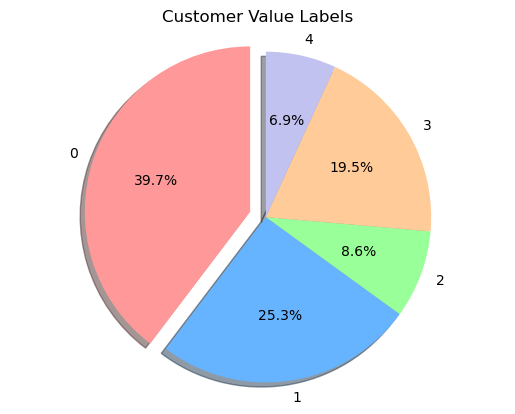

In [44]:
customer_labels = df_with_names.index.tolist()
customer_counts = df_with_names['Sample_Count'].tolist()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

explode = (0.1, 0, 0, 0, 0)
fig1, ax1 = plt.subplots()
ax1.pie(customer_counts, explode=explode, labels=customer_labels, colors=colors, 
        autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')

plt.title('Customer Value Labels')
plt.show()

## Part 2: Churn Prediction (Logistic Regression)

Loyal Core Customers have the longest membership and remain active, making them
the highest-priority segment for retention. Churn is defined as LAST_TO_END > 120
days, reflecting 2-3x the typical high-value flyer activity cycle.

In [45]:
high_value = airline_data[airline_data['Customer Value Labels'] == 'Loyal Core Customers'].copy()
high_value['Churn'] = (high_value['LAST_TO_END'] > 120).astype(int)

print(f'Loyal Core Customers: {len(high_value)}')
print(f'Churn rate: {high_value['Churn'].mean():.1%}')

Loyal Core Customers: 15728
Churn rate: 34.8%


In [46]:
features_columns = [
    'Ration_L1Y_Flight_Count', 'Ration_L1Y_BPS', 'L1Y_BP_SUM',
    'avg_discount', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM',
    'FLIGHT_COUNT', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM'
]

X = high_value[features_columns].values
y = high_value['Churn'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1: {f1_score(y_test, y_pred):.4f}')

Accuracy: 0.7146
AUC: 0.7709
Precision: 0.6323
Recall: 0.4755
F1: 0.5428


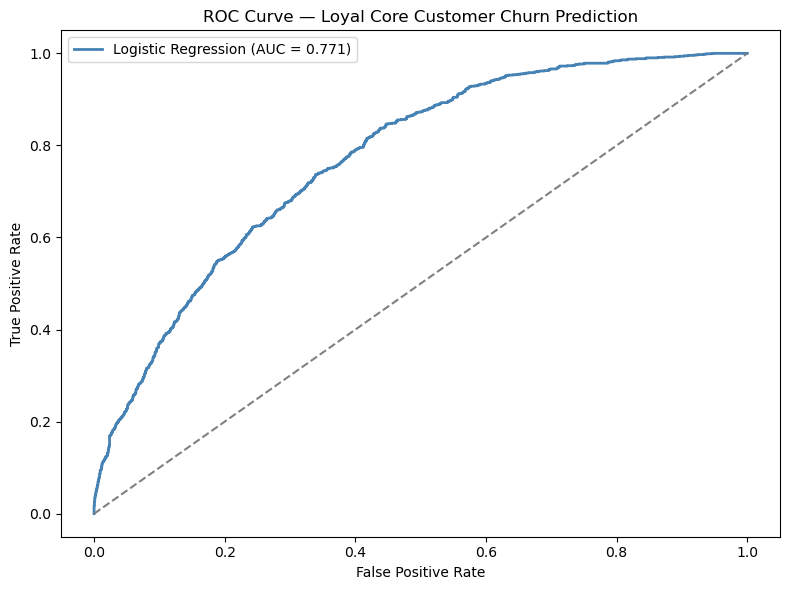

In [47]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Loyal Core Customer Churn Prediction')
ax.legend()
plt.tight_layout()
plt.show()

## Part 3: Churn Prediction (LSTM)


In [48]:
#  LSTM Model, EarlyStopping:

In [49]:
high_value_customers_df = airline_data[airline_data['Customer Value Labels'] == 'Loyal Core Customers']
high_value_customers_df

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME_x,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy
1048,11209,2005/6/29,2005/10/15,Female,6,40.0,2014/3/31,9,80349,0,...,0.444444,0.555556,0.578880,0.421108,3,2.014930,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
1710,29386,2005/11/30,2006/11/28,Male,5,52.0,2014/3/31,16,57375,0,...,0.750000,0.250000,0.053524,0.946458,9,1.833064,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
1763,31130,2009/8/7,2009/8/8,Male,4,47.0,2014/3/31,6,50050,0,...,0.666667,0.333333,0.116881,0.883099,0,0.245802,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
1970,57332,2008/5/15,2008/5/15,Male,4,60.0,2014/3/31,6,27912,0,...,0.666667,0.333333,0.333321,0.666643,0,0.775125,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
2026,2257,2005/7/20,2005/8/17,Female,4,45.0,2014/3/31,13,60768,0,...,0.230769,0.769231,0.806711,0.193273,3,1.990163,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62956,2213,2005/5/18,2005/7/19,Female,4,45.0,2014/3/31,2,0,0,...,1.000000,0.000000,0.000000,0.000000,0,2.064466,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
62960,11699,2008/2/13,2013/7/15,Female,4,73.0,2014/3/31,2,0,0,...,1.000000,0.000000,0.000000,0.000000,0,0.883749,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
62963,10999,2004/12/16,2004/12/18,Female,4,60.0,2014/3/31,2,400,0,...,1.000000,0.000000,0.000000,0.997506,0,2.244917,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...
62974,11163,2005/5/8,2005/8/26,Male,4,34.0,2014/3/31,2,400,0,...,1.000000,0.000000,0.000000,0.997506,1,2.076142,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...


Basic Information
count    15728.000000
mean       104.030900
std         96.009138
min          1.000000
25%         25.000000
50%         76.000000
75%        156.000000
max        535.000000
Name: LAST_TO_END, dtype: float64


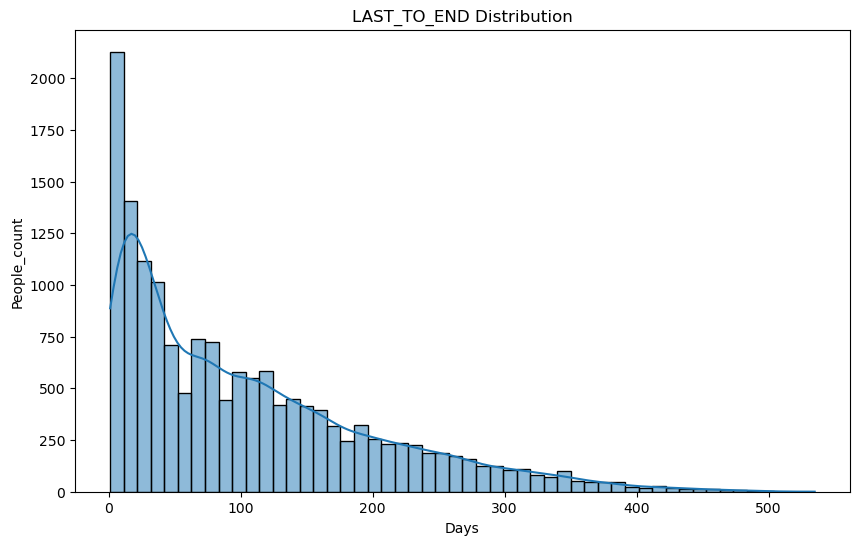

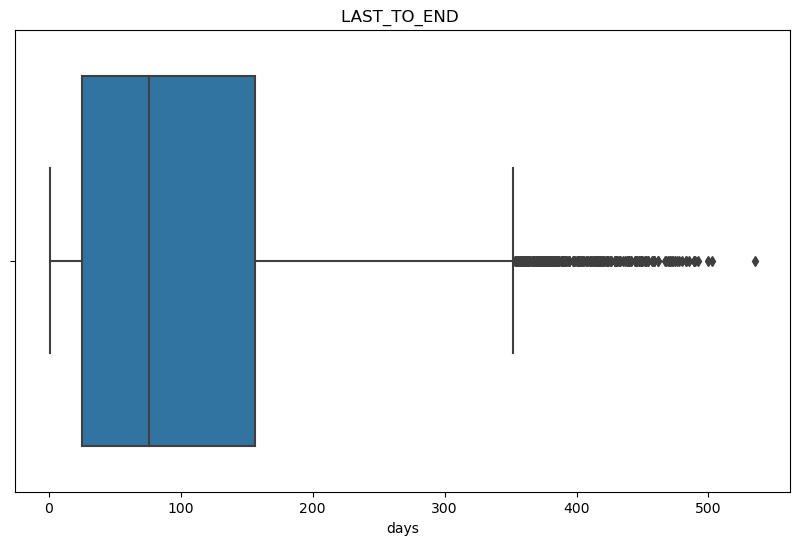

In [50]:
print('Basic Information')
print(high_value_customers_df['LAST_TO_END'].describe())


plt.figure(figsize=(10, 6))
sns.histplot(high_value_customers_df['LAST_TO_END'], kde=True)
plt.title('LAST_TO_END Distribution')
plt.xlabel('Days')
plt.ylabel('People_count')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=high_value_customers_df['LAST_TO_END'])
plt.title('LAST_TO_END ')
plt.xlabel('days')
plt.show()


In [51]:
#120

In [52]:
churn_threshold = 120
high_value_customers_df['Churn'] = high_value_customers_df['LAST_TO_END'] > churn_threshold
high_value_customers_df['Churn'] = high_value_customers_df['Churn'].astype(int)

high_value_customers_df

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME_x,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy,Churn
1048,11209,2005/6/29,2005/10/15,Female,6,40.0,2014/3/31,9,80349,0,...,0.555556,0.578880,0.421108,3,2.014930,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
1710,29386,2005/11/30,2006/11/28,Male,5,52.0,2014/3/31,16,57375,0,...,0.250000,0.053524,0.946458,9,1.833064,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
1763,31130,2009/8/7,2009/8/8,Male,4,47.0,2014/3/31,6,50050,0,...,0.333333,0.116881,0.883099,0,0.245802,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
1970,57332,2008/5/15,2008/5/15,Male,4,60.0,2014/3/31,6,27912,0,...,0.333333,0.333321,0.666643,0,0.775125,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
2026,2257,2005/7/20,2005/8/17,Female,4,45.0,2014/3/31,13,60768,0,...,0.769231,0.806711,0.193273,3,1.990163,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62956,2213,2005/5/18,2005/7/19,Female,4,45.0,2014/3/31,2,0,0,...,0.000000,0.000000,0.000000,0,2.064466,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
62960,11699,2008/2/13,2013/7/15,Female,4,73.0,2014/3/31,2,0,0,...,0.000000,0.000000,0.000000,0,0.883749,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
62963,10999,2004/12/16,2004/12/18,Female,4,60.0,2014/3/31,2,400,0,...,0.000000,0.000000,0.997506,0,2.244917,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,1
62974,11163,2005/5/8,2005/8/26,Male,4,34.0,2014/3/31,2,400,0,...,0.000000,0.000000,0.997506,1,2.076142,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0


In [53]:
features_columns = [
    'Ration_L1Y_Flight_Count', 'Ration_L1Y_BPS', 'L1Y_BP_SUM', 
    'avg_discount', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 
    'FLIGHT_COUNT', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM'
]

X = high_value_customers_df[features_columns]

y = high_value_customers_df['Churn']

In [54]:
target_df=high_value_customers_df.copy()

In [55]:
target_df

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME_x,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy,Churn
1048,11209,2005/6/29,2005/10/15,Female,6,40.0,2014/3/31,9,80349,0,...,0.555556,0.578880,0.421108,3,2.014930,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
1710,29386,2005/11/30,2006/11/28,Male,5,52.0,2014/3/31,16,57375,0,...,0.250000,0.053524,0.946458,9,1.833064,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
1763,31130,2009/8/7,2009/8/8,Male,4,47.0,2014/3/31,6,50050,0,...,0.333333,0.116881,0.883099,0,0.245802,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
1970,57332,2008/5/15,2008/5/15,Male,4,60.0,2014/3/31,6,27912,0,...,0.333333,0.333321,0.666643,0,0.775125,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
2026,2257,2005/7/20,2005/8/17,Female,4,45.0,2014/3/31,13,60768,0,...,0.769231,0.806711,0.193273,3,1.990163,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62956,2213,2005/5/18,2005/7/19,Female,4,45.0,2014/3/31,2,0,0,...,0.000000,0.000000,0.000000,0,2.064466,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
62960,11699,2008/2/13,2013/7/15,Female,4,73.0,2014/3/31,2,0,0,...,0.000000,0.000000,0.000000,0,0.883749,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0
62963,10999,2004/12/16,2004/12/18,Female,4,60.0,2014/3/31,2,400,0,...,0.000000,0.000000,0.997506,0,2.244917,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,1
62974,11163,2005/5/8,2005/8/26,Male,4,34.0,2014/3/31,2,400,0,...,0.000000,0.000000,0.997506,1,2.076142,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0


In [56]:
features_columns = [
    'Ration_L1Y_Flight_Count', 'Ration_L1Y_BPS', 'L1Y_BP_SUM', 
    'avg_discount', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 
    'FLIGHT_COUNT', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM'
]

In [57]:
X = target_df[features_columns].values  
y = target_df['Churn'].values  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [59]:
device

device(type='cuda')

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

In [62]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ''

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
        elif self.best_loss - val_loss >= self.min_delta:
            self.best_model = copy.deepcopy(model.state_dict())
            self.best_loss = val_loss
            self.counter = 0
            self.status = f'Improvement found, counter reset to {self.counter}'
        else:
            self.counter += 1
            self.status = f'No improvement in the last {self.counter} epochs'
            if self.counter >= self.patience:
                self.status = f'Early stopping triggered after {self.counter} epochs.'
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model)
                return True
        return False

In [63]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size=64, output_size=1, layers=1):
        super(LSTMModel, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers=layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.sigmoid = nn.Sigmoid()  
        self.layers = layers  
        
    def forward(self, x):
        h0 = torch.zeros(self.layers, x.size(0), self.hidden_layer_size).to(x.device)
        c0 = torch.zeros(self.layers, x.size(0), self.hidden_layer_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.linear(out[:, -1, :])
        out = self.sigmoid(out)  
        return out


In [64]:
model = LSTMModel(input_size=10, hidden_layer_size=64, output_size=1, layers=2).to(device)

In [65]:
criterion = nn.BCELoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [66]:
early_stopping = EarlyStopping(patience=20, min_delta=0)

In [67]:
X_train_tensor = X_train_tensor.unsqueeze(1)  # Shape becomes (batch_size, 1, features)
X_test_tensor = X_test_tensor.unsqueeze(1)  

In [68]:
print(X_train_tensor.size())  

torch.Size([12582, 1, 10])


In [69]:
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    
    model.eval()
    with torch.no_grad():
        val_output = model(X_test_tensor)
        val_loss = criterion(val_output, y_test_tensor)
    
    print(f'Epoch {epoch+1}, Loss: {loss.item()}, Val Loss: {val_loss.item()}')
    
    early_stop = early_stopping(model, val_loss.item())
    if early_stop:
        print('Early stopping')
        break



Epoch 1, Loss: 0.707036018371582, Val Loss: 0.7048438191413879
Epoch 2, Loss: 0.7056223154067993, Val Loss: 0.7034959197044373
Epoch 3, Loss: 0.7042239904403687, Val Loss: 0.702157199382782
Epoch 4, Loss: 0.7028348445892334, Val Loss: 0.7008218765258789
Epoch 5, Loss: 0.7014490962028503, Val Loss: 0.6994835138320923
Epoch 6, Loss: 0.7000604867935181, Val Loss: 0.6981343030929565
Epoch 7, Loss: 0.6986609697341919, Val Loss: 0.6967658400535583
Epoch 8, Loss: 0.6972424983978271, Val Loss: 0.6953709721565247
Epoch 9, Loss: 0.6957976222038269, Val Loss: 0.6939423084259033
Epoch 10, Loss: 0.6943193674087524, Val Loss: 0.692473292350769
Epoch 11, Loss: 0.6928008198738098, Val Loss: 0.69095778465271
Epoch 12, Loss: 0.6912360787391663, Val Loss: 0.6893888711929321
Epoch 13, Loss: 0.6896185278892517, Val Loss: 0.6877618432044983
Epoch 14, Loss: 0.687943160533905, Val Loss: 0.6860688924789429
Epoch 15, Loss: 0.6862024068832397, Val Loss: 0.6843045949935913
Epoch 16, Loss: 0.6843908429145813, Val 

Epoch 133, Loss: 0.5358753204345703, Val Loss: 0.5406653881072998
Epoch 134, Loss: 0.5356868505477905, Val Loss: 0.5405680537223816
Epoch 135, Loss: 0.5355015993118286, Val Loss: 0.5404745936393738
Epoch 136, Loss: 0.5353202223777771, Val Loss: 0.5403835773468018
Epoch 137, Loss: 0.5351422429084778, Val Loss: 0.5402973294258118
Epoch 138, Loss: 0.534967839717865, Val Loss: 0.5402143001556396
Epoch 139, Loss: 0.5347971320152283, Val Loss: 0.5401365160942078
Epoch 140, Loss: 0.534630537033081, Val Loss: 0.5400614142417908
Epoch 141, Loss: 0.5344669222831726, Val Loss: 0.5399908423423767
Epoch 142, Loss: 0.5343074202537537, Val Loss: 0.539923906326294
Epoch 143, Loss: 0.5341513752937317, Val Loss: 0.5398606657981873
Epoch 144, Loss: 0.5339990854263306, Val Loss: 0.5398012399673462
Epoch 145, Loss: 0.5338504314422607, Val Loss: 0.539745569229126
Epoch 146, Loss: 0.5337056517601013, Val Loss: 0.5396924018859863
Epoch 147, Loss: 0.533564567565918, Val Loss: 0.539642870426178
Epoch 148, Loss:

Epoch 265, Loss: 0.5272820591926575, Val Loss: 0.5360875129699707
Epoch 266, Loss: 0.5272539854049683, Val Loss: 0.5360695719718933
Epoch 267, Loss: 0.5272260904312134, Val Loss: 0.5360504984855652
Epoch 268, Loss: 0.527197539806366, Val Loss: 0.5360323190689087
Epoch 269, Loss: 0.5271698832511902, Val Loss: 0.536013662815094
Epoch 270, Loss: 0.5271419882774353, Val Loss: 0.5359957218170166
Epoch 271, Loss: 0.5271144509315491, Val Loss: 0.5359774231910706
Epoch 272, Loss: 0.5270861387252808, Val Loss: 0.5359606742858887
Epoch 273, Loss: 0.5270594954490662, Val Loss: 0.5359418392181396
Epoch 274, Loss: 0.5270320177078247, Val Loss: 0.5359238386154175
Epoch 275, Loss: 0.5270045399665833, Val Loss: 0.5359066128730774
Epoch 276, Loss: 0.5269773006439209, Val Loss: 0.5358895659446716
Epoch 277, Loss: 0.526950478553772, Val Loss: 0.5358713269233704
Epoch 278, Loss: 0.5269232988357544, Val Loss: 0.5358548760414124
Epoch 279, Loss: 0.5268966555595398, Val Loss: 0.5358375310897827
Epoch 280, Lo

Epoch 397, Loss: 0.5240846872329712, Val Loss: 0.5341507196426392
Epoch 398, Loss: 0.5240627527236938, Val Loss: 0.5341383218765259
Epoch 399, Loss: 0.5240408182144165, Val Loss: 0.5341274738311768
Epoch 400, Loss: 0.5240183472633362, Val Loss: 0.5341155529022217
Epoch 401, Loss: 0.5239956378936768, Val Loss: 0.5341058373451233
Epoch 402, Loss: 0.5239737033843994, Val Loss: 0.5340928435325623
Epoch 403, Loss: 0.5239512920379639, Val Loss: 0.5340815782546997
Epoch 404, Loss: 0.523929238319397, Val Loss: 0.5340699553489685
Epoch 405, Loss: 0.5239071249961853, Val Loss: 0.5340597033500671
Epoch 406, Loss: 0.5238844752311707, Val Loss: 0.5340477228164673
Epoch 407, Loss: 0.5238621830940247, Val Loss: 0.5340367555618286
Epoch 408, Loss: 0.523840069770813, Val Loss: 0.5340242385864258
Epoch 409, Loss: 0.5238175392150879, Val Loss: 0.5340144634246826
Epoch 410, Loss: 0.5237959027290344, Val Loss: 0.5340019464492798
Epoch 411, Loss: 0.5237732529640198, Val Loss: 0.5339915752410889
Epoch 412, L

In [70]:
X_test_tensor.size()

torch.Size([3146, 1, 10])

In [71]:
print(f'Number of samples in X_train_scaled: {X_train_scaled.shape[0]}')
print(f'Number of samples in X_test_scaled: {X_test_scaled.shape[0]}')

Number of samples in X_train_scaled: 12582
Number of samples in X_test_scaled: 3146


In [72]:
features_columns = [
    'Ration_L1Y_Flight_Count', 'Ration_L1Y_BPS', 'L1Y_BP_SUM', 
    'avg_discount', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 
    'FLIGHT_COUNT', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM'
]

X_new = target_df[features_columns].values  

In [73]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [74]:
X_all_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
X_all_tensor = X_all_tensor.unsqueeze(1) 

In [75]:
model.eval()
with torch.no_grad():
    probabilities = model(X_all_tensor).squeeze().cpu().numpy()

In [76]:
high_value_customers_df['Predicted_Churn_Probability'] = probabilities
predicted_labels = (probabilities > 0.5).astype(int)
high_value_customers_df['Predicted_Churn_Label'] = predicted_labels

In [77]:
high_value_customers_df.head(20)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME_x,FLIGHT_COUNT,BP_SUM,EP_SUM_YR_1,...,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy,Churn,Predicted_Churn_Probability,Predicted_Churn_Label
1048,11209,2005/6/29,2005/10/15,Female,6,40.0,2014/3/31,9,80349,0,...,0.421108,3,2.014930,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0,0.465619,0
1710,29386,2005/11/30,2006/11/28,Male,5,52.0,2014/3/31,16,57375,0,...,0.946458,9,1.833064,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0,0.134256,0
1763,31130,2009/8/7,2009/8/8,Male,4,47.0,2014/3/31,6,50050,0,...,0.883099,0,0.245802,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0,0.576641,1
1970,57332,2008/5/15,2008/5/15,Male,4,60.0,2014/3/31,6,27912,0,...,0.666643,0,0.775125,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0,0.369396,0
2026,2257,2005/7/20,2005/8/17,Female,4,45.0,2014/3/31,13,60768,0,...,0.193273,3,1.990163,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,1,0.469053,0
2147,56698,2008/3/5,2008/4/9,Male,4,51.0,2014/3/31,5,58783,0,...,0.604229,0,0.858982,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0,0.581132,1
2223,45852,2006/8/16,2006/11/8,Male,4,69.0,2014/3/31,8,35707,0,...,0.999972,0,1.527712,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0,0.218151,0
2275,10061,2007/1/26,2007/1/26,Female,4,58.0,2014/3/31,6,27912,0,...,0.666643,0,1.335585,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0,0.358947,0
2392,3519,2008/10/27,2009/10/10,Female,4,40.0,2014/3/31,6,27912,0,...,0.666643,0,0.580521,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,1,0.360572,0
2393,29053,2004/12/18,2005/5/6,Male,4,46.0,2014/3/31,6,41872,0,...,0.999976,0,2.242440,Loyal Core Customers,"L,R",15728.0,Anniversary rewards and tier upgrades to reinf...,0,0.210555,0


In [78]:
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor) 
    
test_predicted_labels = (test_predictions.squeeze() > 0.5).cpu().numpy().astype(int)
test_actual_labels = y_test  

In [79]:
# Accuracy
accuracy = accuracy_score(test_actual_labels, test_predicted_labels)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7165


In [80]:
# log loss function
logloss = log_loss(test_actual_labels, test_predictions.squeeze().cpu().numpy())
print(f'Log Loss: {logloss:.4f}')

Log Loss: 0.5331


In [81]:
# ROC-AUC
auc = roc_auc_score(test_actual_labels, test_predictions.squeeze().cpu().numpy())
print(f'AUC: {auc:.4f}')

AUC: 0.7737


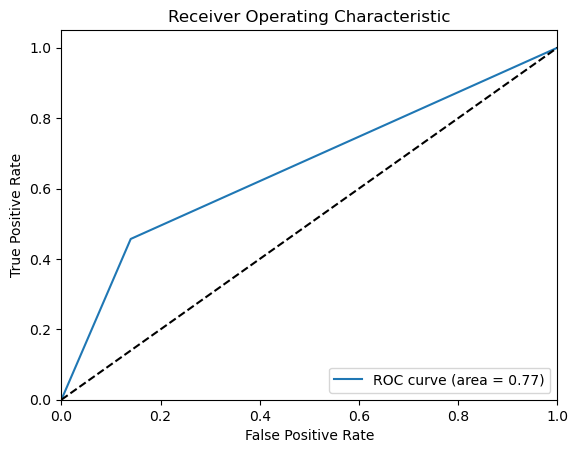

In [82]:
#  ROC curves
fpr, tpr, thresholds = roc_curve(test_actual_labels, test_predicted_labels)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## Export Data for Tableau Dashboard

In [83]:
# 'high_value' refers to Loyal Core Customers segment
high_value_customers_df[['MEMBER_NO','LAST_TO_END','FLIGHT_COUNT','SEG_KM_SUM','avg_discount','Predicted_Churn_Probability','Predicted_Churn_Label']].to_csv('tableau_churn_data.csv', index=False)

In [84]:
df_with_names.to_csv('df_with_names.csv')

In [85]:
airline_features_scaled.to_csv('tableau_all_customers.csv', index=False)

## Conclusion

### Part 1: Customer Segmentation Results

K-Means clustering was evaluated using two metrics: Silhouette Score (optimal k=6, score ≈ 0.28) and Calinski-Harabasz Index (optimal k=4, score ≈ 21,800). k=5 was selected as a compromise between the two, balancing segment granularity with actionable segment sizess, yielding 5 distinct customer segments:

| Segment | Count | % | Behavioral Profile | Marketing Strategy |
|---|---|---|---|---|
| New Growth | 24,611 | 39.7% | Newest members, recently flew but low frequency and miles | Post-enrollment bonus miles, route recommendations based on first flight, and milestone tracking in the app to build flying habits |
| Loyal Core | 15,728 | 25.3% | Longest membership, still actively flying | Anniversary milestone rewards, tenure-based tier upgrades, and birthday bonus miles to creating moments of recognition that build emotional connection |
| VIP | 5,337 | 8.6% | Most frequent flyer, highest miles, most recently active | Dedicated service line, complimentary cabin upgrades, lounge access, and invitation-only member events |
| Lapsed | 12,111 | 19.5% | All metrics below average, longest gap since last flight | Reactivate through low cost, limited time status reinstatement challenges and personalized route deals based on past travel |
| Discount-Sensitive | 4,257 | 6.9% | Near-average behavior except heavy reliance on discounted fares | Targeted promotional fares on low demand routes, leveraging their price sensitivity to improve seat occupancy |

### Part 2: Churn Prediction Results (Logistic Regression)

Built logistic regression model to predict churn for Loyal Core Customers (15,728):

- **Accuracy:** 0.7146
- **AUC:** 0.7709
- **Precision:** 0.6323
- **Recall:** 0.4755
- **F1:** 0.5428

### Part 3: Churn Prediction Results (LSTM)

Built LSTM model to predict churn for Loyal Core Customers (15,728):

- **Accuracy:** 0.7165
- **AUC:** 0.7737
- **Log Loss:** 0.5331

Both models identify loyal core customers at risk of churning, enabling the airline to prioritize retention outreach.

### Business Recommendations

1. **VIP Customers (8.6%):** Dedicated service line, complimentary cabin upgrades, and invitation-only member events
2. **Loyal Core Customers (25.3%):** Anniversary milestone rewards and tenure-based tier upgrades to reinforce loyalty
3. **Lapsed Customers (19.5%):** Low-cost reactivation with time-limited status reinstatement challenges and personalized route deals
4. **Discount-Sensitive Customers (6.9%):** Targeted promotional fares on off-peak and low load factor routes
5. **New Growth Customers (39.7%):** Post-enrollment bonus miles and in-app milestone tracking to convert trial into habit